In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [2]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\dwarf\AppData\Local\Temp\ipykernel_11060\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


In [3]:
data = data.drop(data[data["position"] == "team"].index) 

In [4]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
gameids = missing_playerids["gameid"].unique()
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data[~data["gameid"].isin(gameids)]



there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


In [ ]:
uniq_player_ids = data["playerid"].unique()
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))


In [6]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/9691 [00:00<?, ?it/s]

In [60]:
data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,200.0,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0
1,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,157.0,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0
2,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,241.0,-1552.0,-2465.0,-41.0,1.0,0.0,2.0,1.0,5.0,1.0
3,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,257.0,-2613.0,-1156.0,-6.0,1.0,1.0,2.0,6.0,2.0,0.0
4,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,20.0,-662.0,-734.0,18.0,0.0,2.0,2.0,0.0,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120629,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,188.0,1763.0,3518.0,31.0,2.0,5.0,2.0,0.0,5.0,3.0
120630,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,144.0,1750.0,2364.0,45.0,2.0,8.0,1.0,1.0,4.0,3.0
120631,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,224.0,-125.0,-500.0,-32.0,8.0,5.0,2.0,4.0,4.0,1.0
120632,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,221.0,-541.0,513.0,5.0,0.0,7.0,2.0,2.0,4.0,2.0


In [7]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

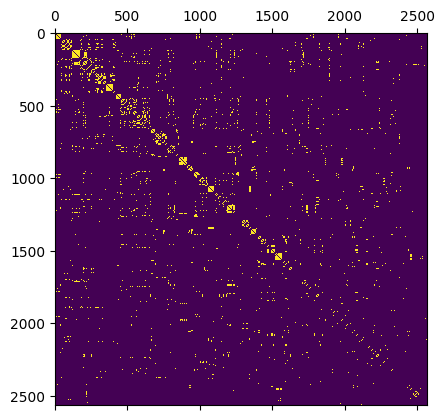

In [8]:
plt.matshow(adj_matrix)

In [9]:
z = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=5)

In [10]:
league_to_region_dict = {"LFL2":"EU", 
"LPL": "CN", 
"LCKC": "KR", 
"LVP SL": "EU", 
"LCK" : "KR", 
"NLC": "EU", 
"LCP": "APAC",
"LEC": "EU",
"HLL": "EU",
"PRM": "EU", 
"LFL": "EU",
"LIT": "EU",
"TCL": "EU",
"HW": "EU",
"LJL": "JP",
"LTA S": "LAT",
"LTA N": "NA",
"RL": "EU",
"NEXO": "EU", 
"CD": "LAT",
"EBL": "EU",
"PCS": "APAC", 
"ROL": "EU",
"LPLOL": "EU", 
"AL": "EU",
"LTA": "NA",
"VCS": "APAC",
"FST": "INT",
"EM": "EU",
"LRS": "LAT",
"LRN": "LAT",
"NACL": "NA", 
"LAS": "KR",
"HC": "EU", 
"PRMP": "EU",
"HM": "EU", 
"CT": "EU",
"Asia Master": "INT",
"MSI": "INT",
"EWC": "INT",
"WLDs": "INT",
"ASI": "INT",
"IC": "EU",
"KeSPA": "KR",
"DCup": "CN"
}

In [11]:
regions = dict.fromkeys(set(league_to_region_dict.values()), 0)
regions

{'EU': 0, 'JP': 0, 'CN': 0, 'LAT': 0, 'KR': 0, 'INT': 0, 'NA': 0, 'APAC': 0}

In [12]:
for i in range(5):
    region_count = dict.fromkeys(set(league_to_region_dict.values()), 0)
    for playerid in uniq_player_ids[z == i]:
        leagues = data[data["playerid"] == playerid]["league"].unique()
        for league in leagues:
            region = league_to_region_dict[league]
            region_count[region] += 1
    print(i)
    print(region_count)
    print("__")


0
{'EU': 2008, 'JP': 0, 'CN': 0, 'LAT': 2, 'KR': 0, 'INT': 0, 'NA': 3, 'APAC': 3}
__
1
{'EU': 56, 'JP': 70, 'CN': 175, 'LAT': 37, 'KR': 298, 'INT': 470, 'NA': 93, 'APAC': 244}
__
2
{'EU': 1, 'JP': 0, 'CN': 0, 'LAT': 103, 'KR': 0, 'INT': 0, 'NA': 124, 'APAC': 0}
__
3
{'EU': 0, 'JP': 0, 'CN': 0, 'LAT': 221, 'KR': 0, 'INT': 0, 'NA': 4, 'APAC': 0}
__
4
{'EU': 216, 'JP': 0, 'CN': 0, 'LAT': 0, 'KR': 0, 'INT': 0, 'NA': 0, 'APAC': 0}
__


In [13]:
z

array([0, 0, 0, ..., 1, 1, 1])

In [14]:
colors = ["#f9c80e", "#f86624", "#ea3546", "#662e9b", "#43bccd"]

color_labels = [colors[x] for x in z]



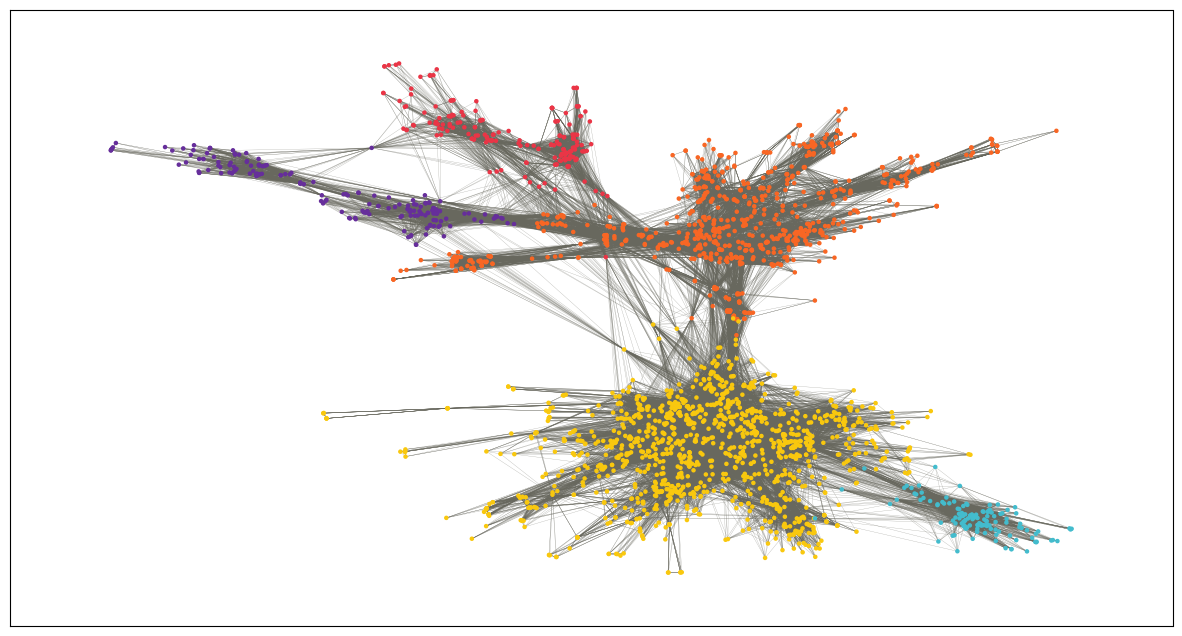

In [15]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

In [19]:
page_ranked = nx.pagerank(G)

In [20]:
page_ranked_sorted = dict(sorted(page_ranked.items(), key=lambda item: item[1],reverse=True))

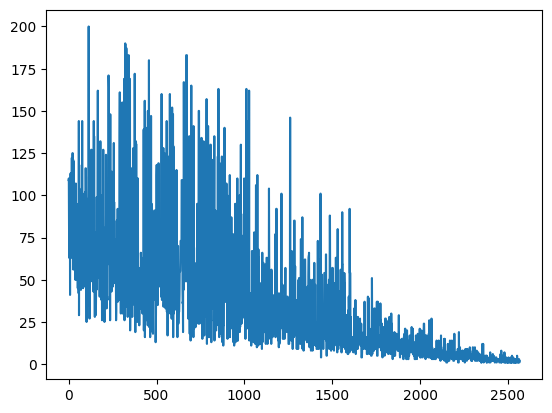

In [ ]:
pr_keys = page_ranked_sorted.keys()
pr_array = []
for val in pr_keys:
    id = list(playerid_to_adj_index.keys())[val]
    pr_id_data = data.loc[data['playerid'] == id]
    pr_array.append(pr_id_data.shape[0])
plt.plot(pr_array)

We see that there is a strong correlation between the number of matches a player is invovled in and their ranking on using pagerank, which is unsurprising as we would assume that players who are highly ranked using pagerank purely based on if they have played eachother or not, are those who have played against the most players, weighted more towards those who are high in pagerank.

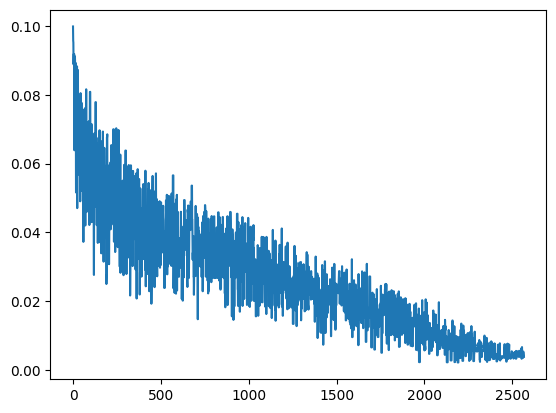

In [32]:
pr_keys = page_ranked_sorted.keys()
pr_array = []
for val in pr_keys:
    sum_val = 0
    adj_vect = adj_matrix[val]
    for i in range(len(adj_vect)):
        if adj_vect [i]== 1:
            sum_val += page_ranked_sorted [i]
    pr_array.append(sum_val)
plt.plot(pr_array)

By summing the pagerank of all opponents at each stage we see an even more clear correlation though still not perfect so lets take a look at some means for the top 50 vs the bottom 50 in page rank to see if something else is being picked up 

In [69]:
pr_keys_list = list(pr_keys)
top_50_player_ids = [list(playerid_to_adj_index.keys())[val] for val in pr_keys_list[:50]]

In [70]:
numeric_cols = data.select_dtypes(include='number').columns

In [91]:
data[numeric_cols] = (data[numeric_cols] - data[numeric_cols].min()) / (data[numeric_cols].max() - data[numeric_cols].min())

In [92]:
mean_values_top_50 = data[data['playerid'].isin(top_50_player_ids)][numeric_cols].mean()
print(mean_values_top_50)

year               0.016678
playoffs           0.296271
game               0.212879
patch              0.427904
participantid      0.527939
                     ...   
assistsat25        0.162176
deathsat25         0.162314
opp_killsat25      0.110081
opp_assistsat25    0.137873
opp_deathsat25     0.191217
Length: 142, dtype: float64


In [93]:
bot_50_player_ids = [list(playerid_to_adj_index.keys())[val] for val in pr_keys_list[len(pr_keys_list)-50:]]

In [94]:
mean_values_bot_50 = data[data['playerid'].isin(bot_50_player_ids)][numeric_cols].mean()
print(mean_values_bot_50)

year               0.047619
playoffs           0.295238
game               0.204762
patch              0.460455
participantid      0.477249
                     ...   
assistsat25        0.156803
deathsat25         0.227041
opp_killsat25      0.143991
opp_assistsat25    0.187075
opp_deathsat25     0.175170
Length: 142, dtype: float64


In [195]:
diff_50 = mean_values_top_50-mean_values_bot_50
diff_50.max()

0.35549819649889136

In [196]:
diff_50.idxmax()

'result'

Interestingly the main difference between the mean values of the top 50, and bottom 50 is the result. However, this is likely due to the very small amount of matches for the lower page rank value teams, as assuming no wins in those few matches (typically 3-4) for the absolute bottom, then this is likely the reason why we can see this difference. Though it also points to a notion that typically worse teams play fewer matches as they play in smaller tournaments, and even then are more likely to lose to better small teams

<AxesSubplot: >

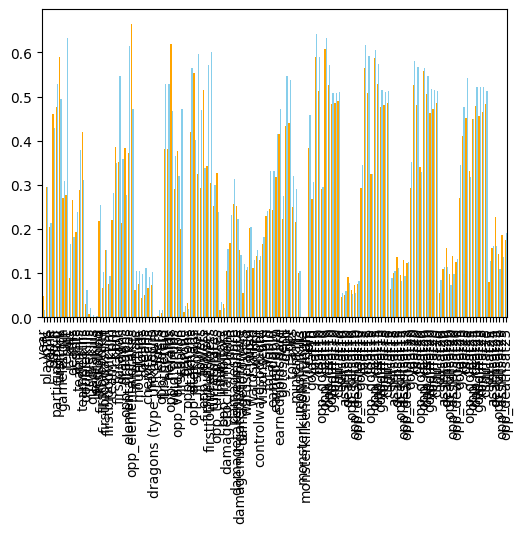

In [ ]:
plt.figure(figsize=(6,4))

mean_values_top_50.plot(kind='bar', color='skyblue', position=0, width=0.4, label='Top 50')

mean_values_bot_50.plot(kind='bar', color='orange', position=1, width=0.4, label='Bottom 50')

(Should change but does at least show some large difference between the two)

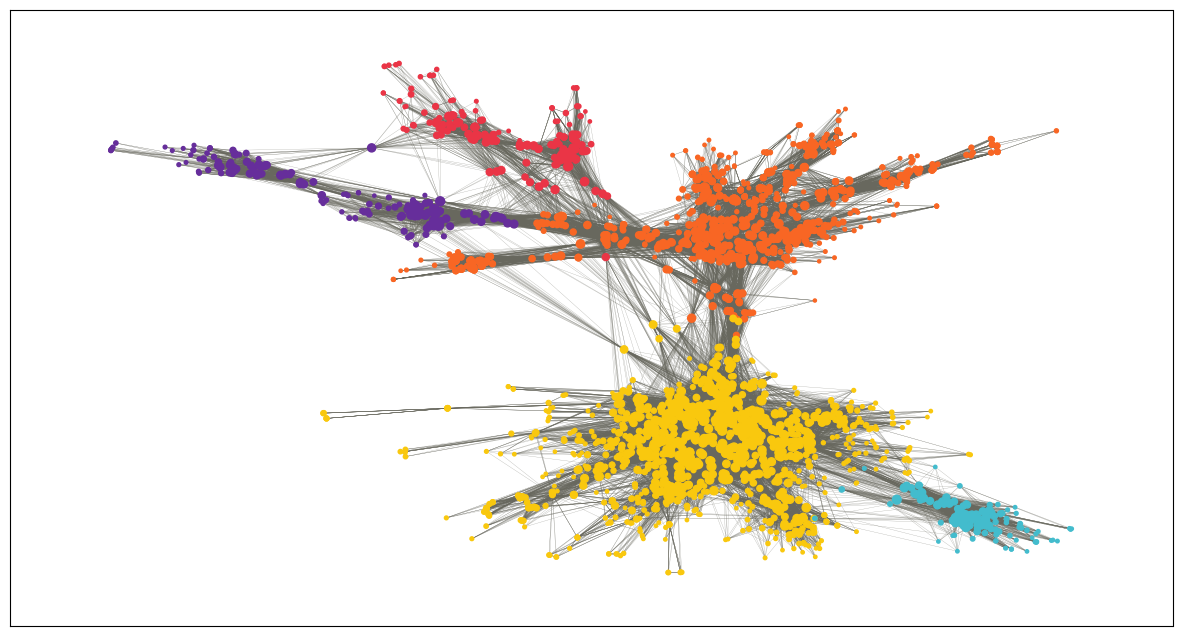

In [101]:
plt.figure(figsize=(15,8))
node_sizes = [50000 * page_ranked[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, layout, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

If we plot as before but now scale each node by the its value in our page ranking we see unsurpisingly that the more connected nodes are often larger

In [197]:
page_ranked_sorted

{456: 0.0010555915051630113,
 453: 0.0009960921368608,
 1114: 0.000975814835675167,
 995: 0.0009658759775636886,
 194: 0.0009650951099559316,
 195: 0.0009650951099559316,
 196: 0.0009650951099559316,
 198: 0.0009650951099559316,
 217: 0.0009627469926214831,
 197: 0.000941795628109293,
 968: 0.0009391942083487988,
 1213: 0.0009051470873872642,
 120: 0.0008828994137691214,
 969: 0.0008748682996666446,
 525: 0.0008685884297957108,
 1277: 0.0008664747579873784,
 579: 0.000861081422029027,
 1078: 0.0008478139350099573,
 1079: 0.0008478139350099573,
 1081: 0.0008478139350099573,
 1082: 0.0008478139350099573,
 562: 0.000844477753987699,
 160: 0.0008383291329408437,
 161: 0.0008383291329408437,
 926: 0.0008374630112910272,
 446: 0.0008301576191108302,
 164: 0.0008271808678452584,
 978: 0.0008208179485710086,
 163: 0.0008168036458408852,
 1216: 0.000816329988048139,
 1007: 0.0008158915600325136,
 32: 0.0008092999437491176,
 1164: 0.0008087392441412341,
 454: 0.0008066019034265254,
 457: 0.00080

In [198]:
playerid = list(playerid_to_adj_index.keys())[456]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
1988,LOLTMNT01_190317,complete,NaN,HLL,0.0,Winter,0.0,2025-01-21 16:53:53,0.00,0.000000,...,0.740864,0.640577,0.568179,0.476087,0.277778,0.366667,0.083333,0.055556,0.000000,0.166667
2223,LOLTMNT01_190394,complete,NaN,HLL,0.0,Winter,0.0,2025-01-22 15:10:37,0.00,0.000000,...,0.837209,0.550130,0.551988,0.463043,0.055556,0.066667,0.083333,0.111111,0.033333,0.083333
2799,LOLTMNT01_189529,complete,NaN,HLL,0.0,Winter,0.0,2025-01-23 17:01:27,0.00,0.000000,...,0.767442,0.608950,0.481110,0.456522,0.444444,0.100000,0.083333,0.111111,0.033333,0.333333
4796,LOLTMNT01_194511,complete,NaN,HLL,0.0,Winter,0.0,2025-01-28 15:27:24,0.00,0.043478,...,0.691030,0.548297,0.522084,0.517391,0.111111,0.133333,0.083333,0.055556,0.133333,0.083333
5139,LOLTMNT01_194983,complete,NaN,HLL,0.0,Winter,0.0,2025-01-29 16:36:28,0.00,0.043478,...,0.734219,0.634784,0.656460,0.460870,0.777778,0.400000,0.083333,0.333333,0.066667,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114080,LOLTMNT06_143465,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:00:28,0.00,0.782609,...,0.797342,0.461693,0.464423,0.486957,0.111111,0.166667,0.083333,0.222222,0.100000,0.000000
114152,LOLTMNT06_144408,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:55:00,0.25,0.782609,...,0.760797,0.534169,0.416621,0.547826,0.222222,0.066667,0.250000,0.277778,0.166667,0.166667
114519,LOLTMNT06_143495,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 15:01:37,0.00,0.782609,...,0.697674,0.523883,0.472023,0.521739,0.111111,0.166667,0.250000,0.166667,0.033333,0.166667
114555,LOLTMNT06_144441,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 16:05:53,0.25,0.782609,...,0.893688,0.480314,0.559808,0.436957,0.000000,0.033333,0.000000,0.000000,0.066667,0.083333


This gives us that the most important player in terms of connections is Axelent from Team Phantasma 

In [103]:
playerid = list(playerid_to_adj_index.keys())[0]
region_count_p0 = dict.fromkeys(set(league_to_region_dict.values()), 0)
leagues = data[data["playerid"] == playerid]["league"].unique()
for league in leagues:
    region = league_to_region_dict[league]
    region_count_p0[region] += 1
region_count_p0

{'EU': 1, 'JP': 0, 'CN': 0, 'LAT': 0, 'KR': 0, 'INT': 0, 'NA': 0, 'APAC': 0}

In [133]:
personlization = {node:0 for node in G.nodes()}
personlization[0]=1
ppreu = nx.pagerank(G,personalization=personlization)
thresh = 0.0001
for k, v in ppreu.items():
    if v < thresh:
        ppreu[k] = 0


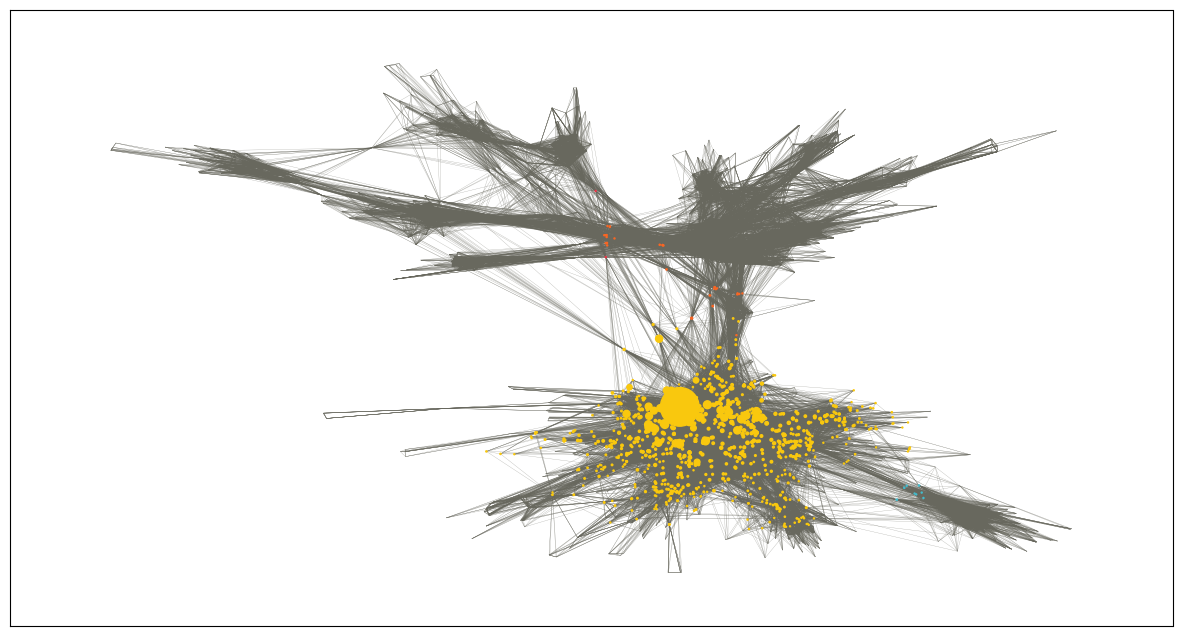

In [186]:
plt.figure(figsize=(15,8))
node_sizes = [5000 * ppreu[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, layout, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

This gives us a pretty decent community around this exact point, so if we looked at only a few players from each region we would be able to find quite a few who are in the same community

In [190]:
ppreu_ids = []
for val in ppreu:
    if ppreu[val]> 0:
        id = list(playerid_to_adj_index.keys())[val]
        ppreu_ids.append(id)


In [192]:
region_count = dict.fromkeys(set(league_to_region_dict.values()), 0)
for playerid in ppreu_ids:
    leagues = data[data["playerid"] == playerid]["league"].unique()
    for league in leagues:
        region = league_to_region_dict[league]
        region_count[region] += 1
print(region_count)
print("__")


{'EU': 1798, 'JP': 0, 'CN': 0, 'LAT': 7, 'KR': 3, 'INT': 48, 'NA': 33, 'APAC': 4}
__


So this method of community detection does work in mostly finding EU players, but is worse than spectral clustering at exclusively grouping them based on region and only one player. We may get better results from including a few different players from each region and changing our cutoff threshold

In [144]:
z_as_list = list(z)
z_as_list.count(1)

789

In [155]:
personlization = {node:0 for node in G.nodes()}
for i in range(len(z_as_list)):
    if z_as_list[i] == 1:
        personlization[i]=1/789
ppr1 = nx.pagerank(G,personalization=personlization)
thresh = 0.000
for k, v in ppr1.items():
    if v < thresh:
        ppr1[k] = 0


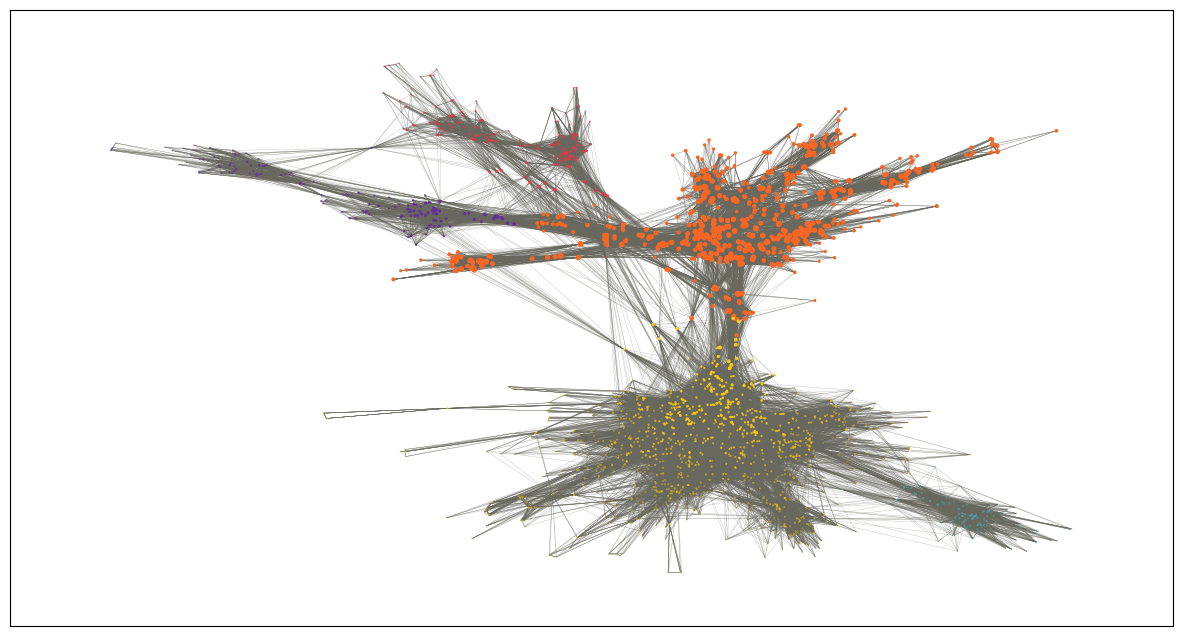

In [156]:
plt.figure(figsize=(15,8))
node_sizes = [5000 * ppr1[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, layout, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

In [151]:
ppr1_sorted = dict(sorted(ppr1.items(), key=lambda item: item[1],reverse=True))

In [157]:
ppr1_sorted_rev = dict(sorted(ppr1.items(), key=lambda item: item[1]))

In [158]:
ppr1_sorted_rev

{2135: 1.214491598472311e-06,
 2136: 1.214491598472311e-06,
 2137: 1.214491598472311e-06,
 1420: 1.2242513597442662e-06,
 2001: 1.2441362919993006e-06,
 1880: 1.2926098851928058e-06,
 1882: 1.2926098851928058e-06,
 1883: 1.2926098851928058e-06,
 2140: 1.305145904690402e-06,
 2537: 1.371734755822731e-06,
 2037: 1.3909104945120313e-06,
 2031: 1.5988777488345085e-06,
 2215: 1.6604076063414238e-06,
 2359: 1.6656418860260733e-06,
 1891: 1.6888072938812593e-06,
 1616: 1.7431823740325645e-06,
 1242: 1.7471672662389764e-06,
 2396: 1.7541548069824217e-06,
 2397: 1.7541548069824217e-06,
 2398: 1.7541548069824217e-06,
 2399: 1.7541548069824217e-06,
 2400: 1.7541548069824217e-06,
 2490: 1.795337947522887e-06,
 2509: 1.8121516003919899e-06,
 804: 1.840105394738884e-06,
 2424: 1.8465842979014793e-06,
 1861: 1.8651809014288617e-06,
 1864: 1.8651809014288617e-06,
 1865: 1.8651809014288617e-06,
 902: 1.869058858329962e-06,
 903: 1.869058858329962e-06,
 1246: 1.870297884552453e-06,
 1987: 1.873425303302

In [152]:
ppr1_sorted

{1078: 0.0026488161831298455,
 1079: 0.0026488161831298455,
 1081: 0.0026488161831298455,
 1082: 0.0026488161831298455,
 1080: 0.002492510576932684,
 118: 0.002352037245039975,
 1525: 0.0022957044844280697,
 1311: 0.0021838782601069874,
 68: 0.0021611868748800923,
 95: 0.002146217531705961,
 321: 0.0021436329607858345,
 1342: 0.002139882397056733,
 80: 0.0021100139933073617,
 48: 0.00209434288425217,
 49: 0.00209434288425217,
 1057: 0.0020786766809310956,
 1059: 0.0020786766809310956,
 1060: 0.0020786766809310956,
 67: 0.0020747537654011035,
 59: 0.0020296334218068935,
 191: 0.0020126459451918354,
 1552: 0.002009561997020137,
 229: 0.0020078642356557404,
 300: 0.0019904349437567825,
 301: 0.0019904349437567825,
 84: 0.001990245236467393,
 839: 0.0019689519411072586,
 413: 0.001968424711599834,
 1341: 0.0019672961964280903,
 1344: 0.0019672961964280903,
 56: 0.001962327645959675,
 119: 0.001960074703746018,
 1072: 0.001956131339649821,
 666: 0.001950139930919492,
 1568: 0.00193598454258

In [154]:
playerid = list(playerid_to_adj_index.keys())[1078]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
9756,LOLTMNT02_210941,complete,NaN,PCS,0.0,Split 1,0.0,2025-02-10 12:03:35,0.00,0.086957,...,0.710963,0.493320,0.451812,0.397826,0.166667,0.100000,0.083333,0.111111,0.033333,0.250000
9797,LOLTMNT02_211380,complete,NaN,PCS,0.0,Split 1,0.0,2025-02-10 12:50:08,0.25,0.086957,...,0.657807,0.559352,0.553750,0.491304,0.166667,0.133333,0.166667,0.111111,0.100000,0.250000
10356,LOLTMNT02_212664,complete,NaN,PCS,0.0,Split 1,0.0,2025-02-12 09:06:07,0.00,0.086957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10397,LOLTMNT02_212667,complete,NaN,PCS,0.0,Split 1,0.0,2025-02-12 09:42:37,0.25,0.086957,...,0.541528,0.465949,0.532933,0.504348,0.055556,0.233333,0.416667,0.277778,0.100000,0.333333
13068,LOLTMNT02_218691,complete,NaN,PCS,0.0,Split 1,0.0,2025-02-17 10:35:22,0.00,0.086957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113244,LOLTMNT03_304778,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 06:53:23,0.25,0.782609,...,0.853821,0.503192,0.428186,0.423913,0.166667,0.066667,0.166667,0.000000,0.066667,0.166667
113916,LOLTMNT03_306017,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-07 08:09:08,0.00,0.782609,...,0.594684,0.580102,0.582278,0.543478,0.000000,0.100000,0.000000,0.000000,0.033333,0.083333
113957,LOLTMNT03_306021,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-07 09:06:39,0.25,0.782609,...,0.637874,0.609896,0.623307,0.571739,0.055556,0.200000,0.000000,0.055556,0.033333,0.250000
114449,LOLTMNT03_305801,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-08 10:37:09,0.00,0.782609,...,0.671096,0.304032,0.300639,0.428261,0.055556,0.100000,0.250000,0.277778,0.100000,0.000000


Player here is Flauren from Deepcross gaming which seems to not be what i would consider the most important team in asia. Though we are likely finding the team that mostly plays only in Asia

In [159]:
playerid = list(playerid_to_adj_index.keys())[2135]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
74645,LOLTMNT02_282874,complete,NaN,NEXO,0.0,Split 3,0.0,2025-06-26 15:10:08,0.00,0.478261,...,0.574751,0.689347,0.591585,0.613043,0.055556,0.033333,0.083333,0.000000,0.033333,0.333333
74664,LOLTMNT02_282895,complete,NaN,NEXO,0.0,Split 3,0.0,2025-06-26 16:05:01,0.25,0.478261,...,0.671096,0.467013,0.509362,0.426087,0.055556,0.200000,0.166667,0.055556,0.033333,0.250000
74693,LOLTMNT02_282912,complete,NaN,NEXO,0.0,Split 3,0.0,2025-06-26 16:55:48,0.50,0.478261,...,0.617940,0.509695,0.541304,0.508696,0.277778,0.166667,0.500000,0.277778,0.166667,0.166667


Reversing unsurprisnlgy finds a very small team that is not at all important, specifically temper and friends

In [136]:
#Then try to use PPR on the spectral clusters, to find the most important player in each group there, tie it back to part 1
#Try on a different graph, where an edge (A,B) means A beat B in a match, give that edge
#  a weight n where n is the number of wins vs that player/team, then use PR on it, then result should be the players with the most wins?


In [163]:
adj_matrix_directed = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

In [177]:
for i in tqdm(range(0, len(data), 10)):
    player_ids_win = []
    player_ids_loss = []
    for j in range(10):
        if data.iloc[i + j]["result"] == 1:
            player_ids_win.append(data.iloc[i + j]["playerid"])
        else:
            player_ids_loss.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids_win:
        for p2 in player_ids_loss:
            adj_matrix_directed[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] += 1

  0%|          | 0/9691 [00:00<?, ?it/s]

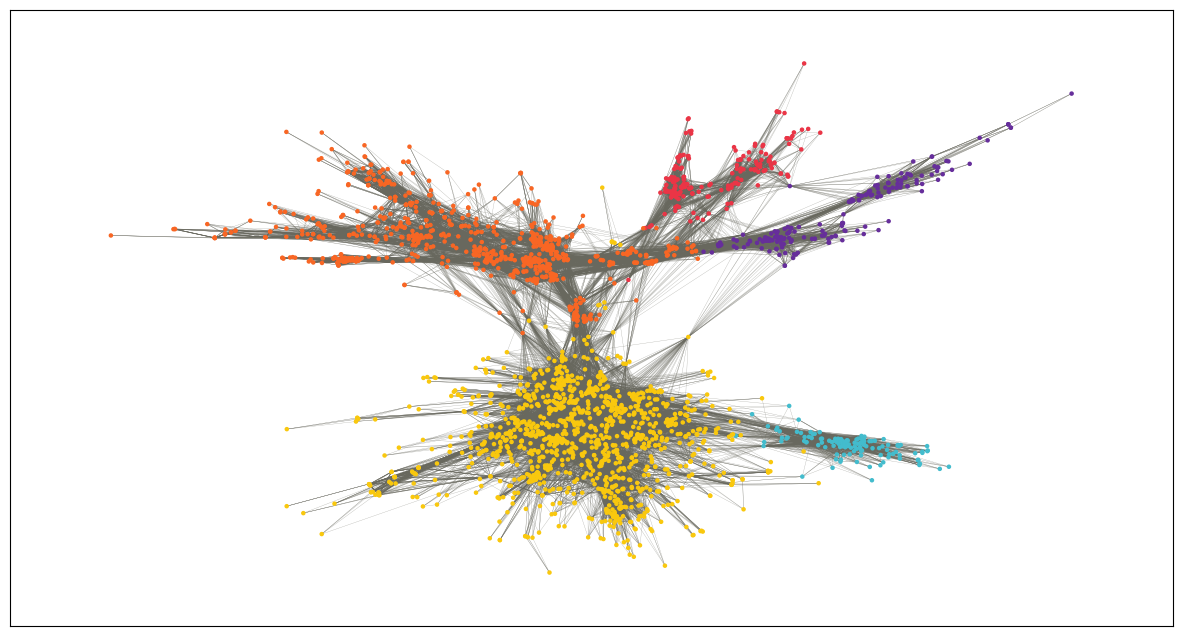

In [178]:
plt.figure(figsize=(15,8))
G_2 = nx.from_numpy_array(adj_matrix_directed)
layout_2 = nx.spring_layout(G_2, seed=1)
nx.draw_networkx_nodes(G_2, layout_2, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G_2, layout_2, width=0.2, alpha=0.6, edge_color = "#68685e")

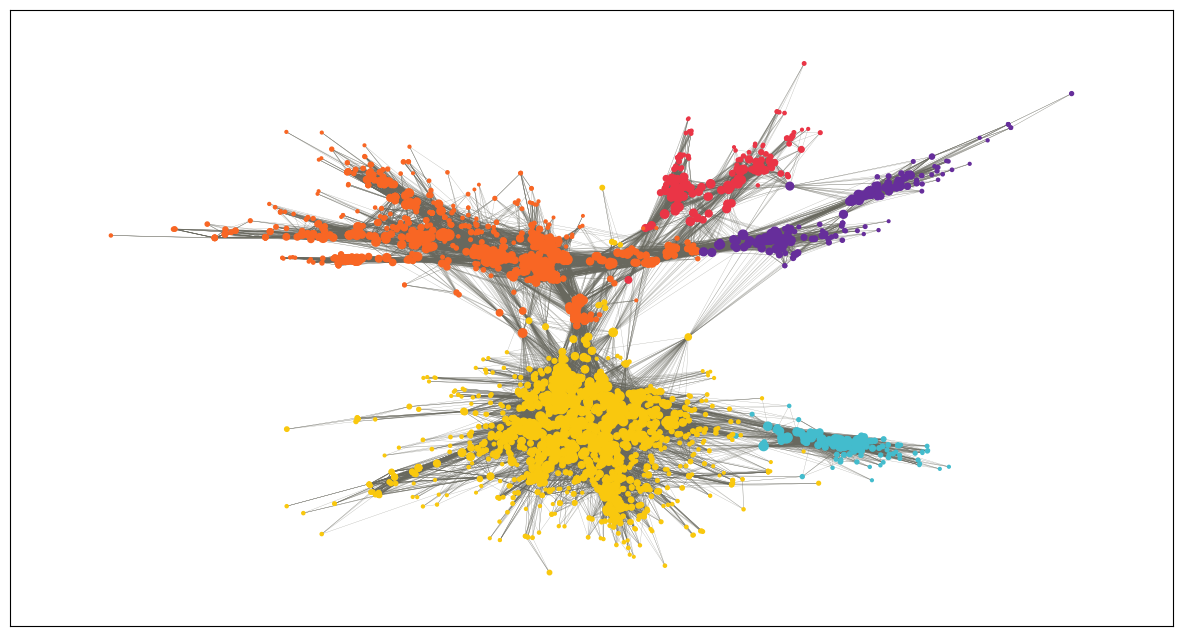

In [179]:
page_ranked_2 = nx.pagerank(G_2)
plt.figure(figsize=(15,8))
node_sizes = [50000 * page_ranked_2[node] for node in G_2.nodes()]
nx.draw_networkx_nodes(G_2, layout_2, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G_2, layout_2, width=0.2, alpha=0.6, edge_color = "#68685e")

In [180]:
pr_2_sorted = dict(sorted(page_ranked_2.items(), key=lambda item: item[1],reverse=True))

In [181]:
pr_2_sorted

{456: 0.0013087186628024604,
 453: 0.001255266996870932,
 454: 0.0011765626390192697,
 457: 0.0011765626390192697,
 194: 0.0011720611452636946,
 195: 0.0011720611452636946,
 196: 0.0011720611452636946,
 198: 0.0011720611452636946,
 1213: 0.0011641519895911638,
 1209: 0.001160967807127532,
 1211: 0.001160967807127532,
 197: 0.0011549704341263438,
 1078: 0.0011141403919272706,
 1079: 0.0011141403919272706,
 1081: 0.0011141403919272706,
 1082: 0.0011141403919272706,
 455: 0.0011054040865644537,
 160: 0.0010679778593260549,
 161: 0.0010679778593260549,
 164: 0.0010562111535778167,
 1173: 0.0010398174366289428,
 163: 0.0010343008941780408,
 1196: 0.0009956648682110107,
 626: 0.000994722756964052,
 628: 0.000994722756964052,
 629: 0.000994722756964052,
 1007: 0.0009871122253959934,
 548: 0.0009740469941611949,
 550: 0.0009740469941611949,
 551: 0.0009740469941611949,
 1198: 0.0009614587642667256,
 1171: 0.000938202809704481,
 969: 0.000929428655364017,
 579: 0.0009278860593010964,
 1114: 0.0

In [182]:
playerid = list(playerid_to_adj_index.keys())[456]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
1988,LOLTMNT01_190317,complete,NaN,HLL,0.0,Winter,0.0,2025-01-21 16:53:53,0.00,0.000000,...,0.740864,0.640577,0.568179,0.476087,0.277778,0.366667,0.083333,0.055556,0.000000,0.166667
2223,LOLTMNT01_190394,complete,NaN,HLL,0.0,Winter,0.0,2025-01-22 15:10:37,0.00,0.000000,...,0.837209,0.550130,0.551988,0.463043,0.055556,0.066667,0.083333,0.111111,0.033333,0.083333
2799,LOLTMNT01_189529,complete,NaN,HLL,0.0,Winter,0.0,2025-01-23 17:01:27,0.00,0.000000,...,0.767442,0.608950,0.481110,0.456522,0.444444,0.100000,0.083333,0.111111,0.033333,0.333333
4796,LOLTMNT01_194511,complete,NaN,HLL,0.0,Winter,0.0,2025-01-28 15:27:24,0.00,0.043478,...,0.691030,0.548297,0.522084,0.517391,0.111111,0.133333,0.083333,0.055556,0.133333,0.083333
5139,LOLTMNT01_194983,complete,NaN,HLL,0.0,Winter,0.0,2025-01-29 16:36:28,0.00,0.043478,...,0.734219,0.634784,0.656460,0.460870,0.777778,0.400000,0.083333,0.333333,0.066667,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114080,LOLTMNT06_143465,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:00:28,0.00,0.782609,...,0.797342,0.461693,0.464423,0.486957,0.111111,0.166667,0.083333,0.222222,0.100000,0.000000
114152,LOLTMNT06_144408,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:55:00,0.25,0.782609,...,0.760797,0.534169,0.416621,0.547826,0.222222,0.066667,0.250000,0.277778,0.166667,0.166667
114519,LOLTMNT06_143495,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 15:01:37,0.00,0.782609,...,0.697674,0.523883,0.472023,0.521739,0.111111,0.166667,0.250000,0.166667,0.033333,0.166667
114555,LOLTMNT06_144441,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 16:05:53,0.25,0.782609,...,0.893688,0.480314,0.559808,0.436957,0.000000,0.033333,0.000000,0.000000,0.066667,0.083333


Gives us axelent from team Phantasma, which does not seem right 

In [183]:
pr_2_sorted_rev = dict(sorted(page_ranked_2.items(), key=lambda item: item[1]))
pr_2_sorted_rev

{2531: 6.597678022176607e-05,
 2214: 6.646874319056353e-05,
 1241: 6.689481723889945e-05,
 2549: 6.938069331217619e-05,
 2213: 7.149775834263512e-05,
 1990: 7.161945817861475e-05,
 1251: 7.210189029520698e-05,
 1186: 7.214541442097988e-05,
 1188: 7.214541442097988e-05,
 1751: 7.237351647211022e-05,
 1753: 7.237351647211022e-05,
 1754: 7.237351647211022e-05,
 1755: 7.237351647211022e-05,
 1981: 7.237900117956742e-05,
 2357: 7.242617510426098e-05,
 2403: 7.311631649305967e-05,
 1056: 7.318480010504393e-05,
 1795: 7.33286522433901e-05,
 2259: 7.378681987646045e-05,
 2263: 7.378681987646045e-05,
 1891: 7.38134623325706e-05,
 2182: 7.393220583649943e-05,
 532: 7.499576500942414e-05,
 1918: 7.516233225523272e-05,
 2308: 7.552468075168654e-05,
 2423: 7.568586388931767e-05,
 2428: 7.572222138373347e-05,
 2429: 7.572222138373347e-05,
 956: 7.574372730902542e-05,
 2280: 7.579610535214794e-05,
 767: 7.616003849329766e-05,
 1850: 7.623185950649408e-05,
 1828: 7.634806964574956e-05,
 2363: 7.647991

In [184]:
playerid = list(playerid_to_adj_index.keys())[2531]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
113373,LOLTMNT03_304831,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 09:59:28,0.00,0.782609,...,0.093023,0.460806,0.433418,0.489130,0.0,0.300000,0.416667,0.055556,0.400000,0.166667
113404,LOLTMNT03_304839,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 10:57:19,0.25,0.782609,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113445,LOLTMNT03_304849,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 11:40:15,0.50,0.782609,...,0.089701,0.446855,0.477531,0.497826,0.0,0.233333,0.250000,0.055556,0.233333,0.000000


Gives Sirius from team Gen.G Global Academy